# NB00 - Preparación de datos y análisis exploratorio con Titanic

Esta segunda pista repite el recorrido pedagógico del curso usando el dataset `titanic` de seaborn. El objetivo binario es **survived**: `1` significa que el pasajero sobrevivió y `0` que falleció.

La gracia didáctica del Titanic es distinta a Iris: hay variables mixtas, valores faltantes, categorías, variables derivadas y una tasa base desbalanceada de supervivencia. Por eso el primer notebook se concentra en preparar un pipeline reproducible antes de modelar.


In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks_2":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)

from src.titanic_utils import (
    CATEGORICAL_FEATURES,
    DUPLICATE_OR_DERIVED_COLUMNS,
    FEATURE_COLUMNS,
    LEAKAGE_COLUMNS,
    NUMERIC_FEATURES,
    RANDOM_STATE,
    get_train_test_split,
    load_titanic_binary,
    save_processed_splits,
    set_plot_style,
)

set_plot_style()


## 1. Carga de Titanic y definición del problema

`seaborn.load_dataset("titanic")` trae 891 pasajeros y 15 columnas. Para una regresión logística binaria, la variable respuesta natural es `survived`. La clase positiva será **sobrevivió = 1**, porque así las probabilidades estimadas se interpretan como probabilidad de supervivencia.


In [2]:
X, y, df = load_titanic_binary()

print(f"Filas y columnas originales: {df.shape}")
print(f"Variables predictoras seleccionadas: {X.shape[1]}")
display(df.head())


Filas y columnas originales: (891, 15)
Variables predictoras seleccionadas: 8


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Variables excluidas y riesgo de fuga de información

No todas las columnas de seaborn deben entrar al modelo. `alive` es una traducción directa de `survived`, así que incluirla sería fuga de información. `class` duplica `pclass`; `embark_town` duplica `embarked`; `who` y `adult_male` son derivadas de sexo/edad; `deck` tiene demasiados faltantes para esta primera ruta.

Conservar solo `pclass`, `age`, `sibsp`, `parch`, `fare`, `sex`, `embarked` y `alone` deja un problema suficientemente realista sin esconder el aprendizaje detrás de ingeniería de variables excesiva.


In [3]:
audit = (
    df.dtypes.astype(str)
    .rename("dtype")
    .to_frame()
    .join(df.isna().mean().mul(100).rename("missing_pct"))
)
audit["uso"] = "excluida"
audit.loc[FEATURE_COLUMNS, "uso"] = "predictora"
audit.loc[["survived"], "uso"] = "objetivo"
audit.loc[LEAKAGE_COLUMNS, "uso"] = "fuga: duplica el objetivo"
audit.loc[DUPLICATE_OR_DERIVED_COLUMNS, "uso"] = "redundante/derivada"
display(audit)


,dtype,missing_pct,uso
survived,int64,0.0000,objetivo
pclass,int64,0.0000,predictora
sex,object,0.0000,predictora
age,float64,19.8653,predictora
sibsp,int64,0.0000,predictora
parch,int64,0.0000,predictora
fare,float64,0.0000,predictora
embarked,object,0.2245,predictora
class,category,0.0000,redundante/derivada
who,object,0.0000,redundante/derivada


## 3. Clase positiva y balance de clases

La supervivencia no está perfectamente balanceada: sobreviven menos pasajeros de los que fallecen. Este hecho será importante cuando comparemos accuracy, curvas precision-recall y aprendizaje sensible al costo.


,n,proporcion
survived,,
fallecido (0),549,0.6162
sobreviviente (1),342,0.3838


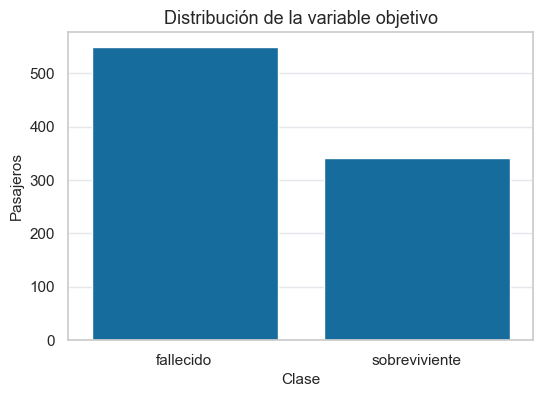

In [4]:
class_balance = (
    y.value_counts()
    .sort_index()
    .rename(index={0: "fallecido (0)", 1: "sobreviviente (1)"})
    .to_frame("n")
)
class_balance["proporcion"] = class_balance["n"] / class_balance["n"].sum()
display(class_balance)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=y.map({0: "fallecido", 1: "sobreviviente"}), ax=ax)
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Clase")
ax.set_ylabel("Pasajeros")
plt.show()


## 4. EDA visual: supervivencia por variables clave

La literatura aplicada de regresión logística recomienda mirar tasas base por grupos antes de interpretar coeficientes. En Titanic, sexo, clase y edad muestran señales fuertes; tarifa y puerto de embarque aportan información adicional pero también reflejan estructura social y económica.


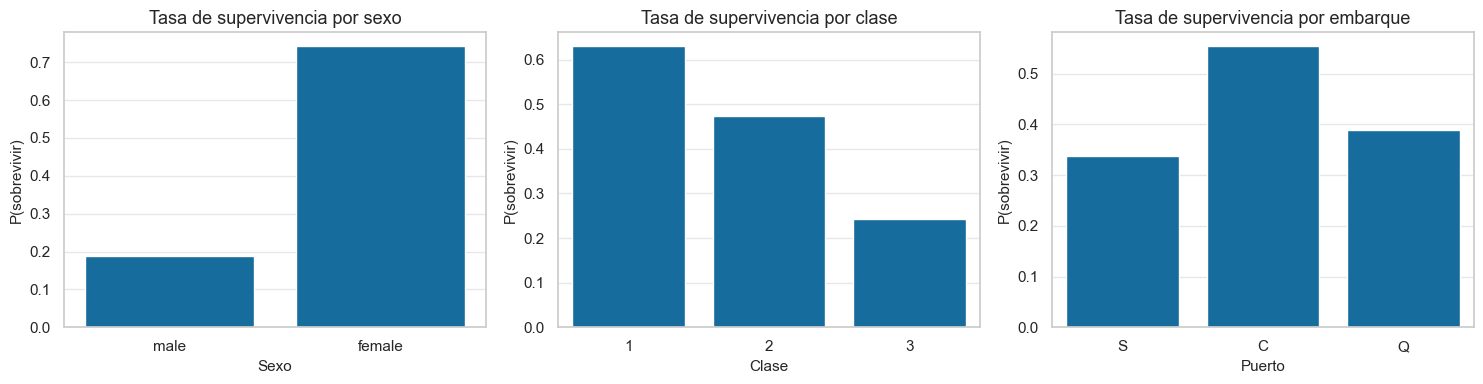

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=df, x="sex", y="survived", errorbar=None, ax=axes[0])
axes[0].set_title("Tasa de supervivencia por sexo")
axes[0].set_xlabel("Sexo")
axes[0].set_ylabel("P(sobrevivir)")

sns.barplot(data=df, x="pclass", y="survived", errorbar=None, ax=axes[1])
axes[1].set_title("Tasa de supervivencia por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("P(sobrevivir)")

sns.barplot(data=df, x="embarked", y="survived", errorbar=None, ax=axes[2])
axes[2].set_title("Tasa de supervivencia por embarque")
axes[2].set_xlabel("Puerto")
axes[2].set_ylabel("P(sobrevivir)")

fig.tight_layout()
plt.show()


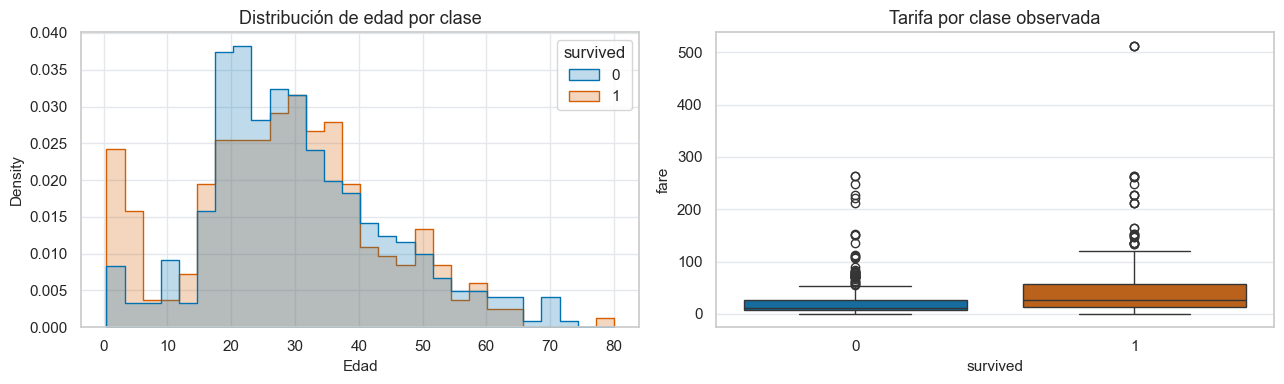

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(
    data=df,
    x="age",
    hue="survived",
    bins=28,
    stat="density",
    common_norm=False,
    element="step",
    ax=axes[0],
)
axes[0].set_title("Distribución de edad por clase")
axes[0].set_xlabel("Edad")

sns.boxplot(
    data=df,
    x="survived",
    y="fare",
    hue="survived",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Tarifa por clase observada")
axes[1].set_xlabel("survived")
axes[1].set_ylabel("fare")

fig.tight_layout()
plt.show()


tasa_supervivencia    n
sex    pclass                         
female 1                   0.9681   94
       2                   0.9211   76
       3                   0.5000  144
male   1                   0.3689  122
       2                   0.1574  108
       3                   0.1354  347

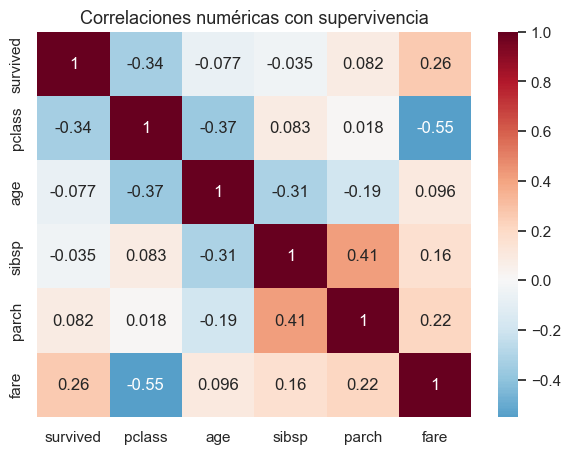

In [7]:
group_rates = (
    df.groupby(["sex", "pclass"], observed=True)["survived"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "tasa_supervivencia", "count": "n"})
)
display(group_rates)

numeric_corr = df[["survived", "pclass", "age", "sibsp", "parch", "fare"]].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(numeric_corr, annot=True, cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlaciones numéricas con supervivencia")
plt.show()


## 5. Split estratificado, imputación, one-hot encoding y escalado

Usamos `test_size=0.30` para reservar 30% de los datos como prueba, una proporción común en datasets pequeños. `random_state=42` fija la reproducibilidad. `stratify=y` conserva la proporción de supervivientes en train y test.

El preprocesamiento se ajusta **solo con train**: mediana para numéricas, moda para categóricas, `OneHotEncoder(drop="first")` para evitar redundancia exacta entre dummies y `StandardScaler` para que los penaltis L1/L2 comparen coeficientes en una escala común.


In [8]:
split_data = get_train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)

print("Train crudo:", split_data["X_train"].shape)
print("Test crudo:", split_data["X_test"].shape)
print("Train procesado:", split_data["X_train_processed"].shape)
print("Test procesado:", split_data["X_test_processed"].shape)
print("Variables procesadas:")
print(split_data["feature_names"])

display(
    pd.DataFrame(
        {
            "train": split_data["y_train"].value_counts(normalize=True).sort_index(),
            "test": split_data["y_test"].value_counts(normalize=True).sort_index(),
        }
    ).rename(index={0: "fallecido", 1: "sobreviviente"})
)


Train crudo: (623, 8)
Test crudo: (268, 8)
Train procesado: (623, 9)
Test procesado: (268, 9)
Variables procesadas:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S', 'alone_True']


,train,test
survived,,
fallecido,0.6164,0.6157
sobreviviente,0.3836,0.3843


## 6. Guardado de splits compartidos

Los demás notebooks cargan el mismo archivo `titanic_binary_splits.npz`. Esto evita que cada tema cambie por azar de split o por diferencias de preprocesamiento.


In [9]:
output_path = save_processed_splits(split_data, DATA_DIR)
print(f"Splits guardados en: {output_path.relative_to(PROJECT_ROOT)}")
print(f"Faltantes en train procesado: {split_data['X_train_processed'].isna().sum().sum()}")
print(f"Faltantes en test procesado: {split_data['X_test_processed'].isna().sum().sum()}")


Splits guardados en: data\processed\titanic_binary_splits.npz
Faltantes en train procesado: 0
Faltantes en test procesado: 0


## Resumen y conexión con la literatura

Titanic permite estudiar regresión logística en un escenario más cercano a datos tabulares reales: faltantes, variables categóricas, variables derivadas y desbalance moderado. La preparación sigue la lógica recomendada en textos aplicados como Hosmer, Lemeshow y Sturdivant: definir cuidadosamente el evento, auditar variables antes de modelar y separar preprocesamiento de evaluación.
